In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Example: If you uploaded my_dataset.zip directly to /content/
ZIP_FILE = "/content/drive/MyDrive/MindScan/binary_dataset.zip"

# Destination folder where the extracted files will go (e.g., /content/data/)
DEST_FOLDER = "/content/MindScan/"

# Create the destination folder first
!mkdir -p {DEST_FOLDER}

# Use the unzip command
# -q makes it quiet (no long output list), -d sets the destination directory
!unzip -q {ZIP_FILE} -d {DEST_FOLDER}

print(f"Extraction complete. Data is ready in: {DEST_FOLDER}")

Extraction complete. Data is ready in: /content/MindScan/


Train class counts: Counter({1: 4117, 0: 1595})
Test class counts: Counter({1: 906, 0: 405})


Epoch 1 batches: 100%|██████████| 100/100 [00:20<00:00,  4.04it/s]
                                                                  

Epoch 1 | Train Loss: 0.0895, Acc: 96.90%


Training Epochs:   5%|▌         | 1/20 [00:25<08:00, 25.32s/it]

Epoch [1/20] | Train Loss: 0.0895, Acc: 96.90% | Val Loss: 0.0776, Acc: 97.03%


...


Epoch 6 batches: 100%|██████████| 100/100 [00:16<00:00,  6.90it/s]
                                                                  

Epoch 6 | Train Loss: 0.0006, Acc: 100.00%


Training Epochs:  25%|██▌       | 5/20 [02:09<06:28, 25.87s/it]

Epoch [6/20] | Train Loss: 0.0006, Acc: 100.00% | Val Loss: 0.1004, Acc: 97.33%
Early stopping at epoch 6
✅ Best model saved to resnet18_binary_tumor.pth



Classification Report:
              precision    recall  f1-score   support

     notumor       0.93      1.00      0.97       405
       tumor       1.00      0.97      0.98       906

    accuracy                           0.98      1311
   macro avg       0.97      0.98      0.97      1311
weighted avg       0.98      0.98      0.98      1311



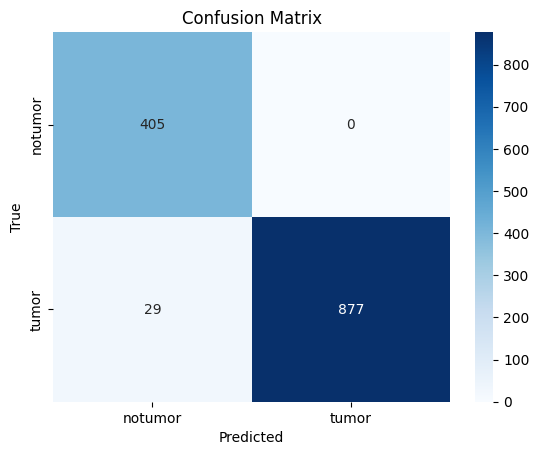

In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import trange, tqdm

# ===========================
# 1️⃣ CONFIGURATION
# ===========================
DATA_ROOT = "/content/MindScan/binary_dataset"  # Path to normalized data
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 3  # Early stopping patience
BEST_MODEL_PATH = "resnet18_binary_tumor.pth"

# ===========================
# 2️⃣ CUSTOM DATASET
# ===========================
class NpyDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data, self.labels = [], []
        self.transform = transform
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for cls_name in self.classes:
            cls_dir = os.path.join(data_dir, cls_name)
            if not os.path.isdir(cls_dir):
                continue
            for f in os.listdir(cls_dir):
                if f.endswith('.npy'):
                    self.data.append(os.path.join(cls_dir, f))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = np.load(self.data[idx])
        x = torch.tensor(x, dtype=torch.float32)

        # Ensure 3-channel (C, H, W)
        if x.ndim == 2:  # (H, W)
            x = x.unsqueeze(0).repeat(3, 1, 1)
        elif x.ndim == 3:
            if x.shape[0] == 1:
                x = x.repeat(3, 1, 1)
            elif x.shape[0] == 2:
                x = torch.cat([x[0:1], x], dim=0)
            elif x.shape[0] > 3:
                x = x[:3, :, :]
            # assume already (C,H,W) if x.shape[0]==3

        # Apply transform
        if self.transform:
            x = self.transform(x)

        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

# ===========================
# 3️⃣ TRANSFORMS
# ===========================
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ===========================
# 4️⃣ LOAD DATA
# ===========================
train_dataset = NpyDataset(TRAIN_DIR, transform=transform)
test_dataset  = NpyDataset(TEST_DIR, transform=transform)

print("Train class counts:", Counter(train_dataset.labels))
print("Test class counts:", Counter(test_dataset.labels))

# Optional: balance training dataset
def balance_dataset(dataset):
    counts = Counter(dataset.labels)
    min_count = min(counts.values())
    idxs = []
    for label in counts.keys():
        label_idxs = [i for i, y in enumerate(dataset.labels) if y == label]
        idxs.extend(np.random.choice(label_idxs, min_count, replace=False))
    return Subset(dataset, idxs)

balanced_train = balance_dataset(train_dataset)

train_loader = DataLoader(balanced_train, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===========================
# 5️⃣ MODEL DEFINITION
# ===========================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze early layers
for param in model.layer1.parameters():
    param.requires_grad = False
for param in model.layer2.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 2)  # Binary classification
)

model = model.to(DEVICE)

# ===========================
# 6️⃣ LOSS AND OPTIMIZER
# ===========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ===========================
# 7️⃣ TRAINING LOOP WITH EARLY STOPPING
# ===========================
best_val_loss = float("inf")
wait = 0

for epoch in trange(1, 1 + EPOCHS, desc="Training Epochs"):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # tqdm for batches
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} batches", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)   # ✅ define train_loss
    train_acc = 100 * correct / total
    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(test_loader.dataset)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"✅ Best model saved to {BEST_MODEL_PATH}")

# ===========================
# 8️⃣ EVALUATION
# ===========================
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
